

---


# Redes Neuronales Multicapa
Implementación de un MLP
Este cuaderno práctico tiene como objetivo demostrar la construcción de un Perceptrón Multicapa (MLP) para resolver un problema de clasificación binaria. Utilizaremos el caso de Evaluación de Riesgo Crediticio para ilustrar cada componente.


## 1. Configuración del Entorno

Primero, importamos las librerías necesarias. TensorFlow es el motor principal para construir y entrenar la red, mientras que NumPy nos permite manejar los vectores de datos.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# Verificamos la versión de TensorFlow
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


## 2. Definición de la Arquitectura de la Red
Como vimos en la teoría, la arquitectura se define por niveles. Cada capa tiene un propósito específico:

### Capa de Entrada (Input Layer)
La capa de entrada debe coincidir con la dimensionalidad de nuestros datos preprocesados. En nuestro ejemplo de crédito, tras normalizar y codificar las variables, contamos con 7 neuronas de entrada.

### Capas Ocultas (Hidden Layers)
Utilizaremos dos capas ocultas para detectar patrones no lineales.

* Capa 1: 8 neuronas con función de activación ReLU.

* Capa 2: 4 neuronas con función de activación ReLU.

* Capa de Salida (Output Layer): Para una clasificación binaria, utilizamos 1 neurona con función de activación Sigmoide, lo que nos entregará una probabilidad entre 0 y 1.

In [ ]:
def crear_modelo():
    model = models.Sequential([
        # Capa de Entrada explícita
        layers.Input(shape=(7,), name='Capa_de_Entrada'),
        # Primera Capa Oculta
        layers.Dense(8, activation='relu', name='Capa_Oculta_1'),

        # Segunda Capa Oculta
        layers.Dense(4, activation='relu', name='Capa_Oculta_2'),

        # Capa de Salida
        layers.Dense(1, activation='sigmoid', name='Capa_de_Salida')
    ])

    return model

# Instanciamos el modelo y vemos su estructura
mlp_model = crear_modelo()
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_de_Salida (Dense)          │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Compilación del Modelo: El Motor de Aprendizaje
Para que la red pueda aplicar el algoritmo de Backpropagation, debemos definir tres elementos clave:

1. **Optimizador:** Utilizaremos Adam, que ajusta la Tasa de Aprendizaje de forma adaptativa.

2. **Función de Pérdida:** Para clasificación binaria, la función estándar es binary_crossentropy.

3. **Métrica:** Queremos monitorear el accuracy (precisión) durante el entrenamiento.

In [ ]:
mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 4. Entrenamiento y Control de Épocas
El entrenamiento es un proceso iterativo. Para evitar el sobreajuste, implementaremos Early Stopping, que detendrá el proceso si el error en los datos de validación deja de mejorar.

In [ ]:
# Definimos la técnica de Parada Temprana
callback_parada = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,          # Esperar 15 épocas sin mejora antes de parar
    restore_best_weights=True
)

# Simulamos datos de entrenamiento y validación (7 características)
X_train = np.random.rand(1000, 7)
y_train = np.random.randint(2, size=(1000, 1))

# Iniciamos el entrenamiento
print("Iniciando entrenamiento...")
history = mlp_model.fit(
    X_train, y_train,
    epochs=1000,           # Máximo de épocas permitidas
    batch_size=32,
    validation_split=0.2,  # 20% de los datos para validación interna
    callbacks=[callback_parada],
    verbose=1
)

Iniciando entrenamiento...
Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4775 - loss: 0.6968 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5200 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5200 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5200 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5200 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5200 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5213 - loss: 0.6924 - val_accuracy: 0.5050 - val_loss: 0.6941
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5238 - los

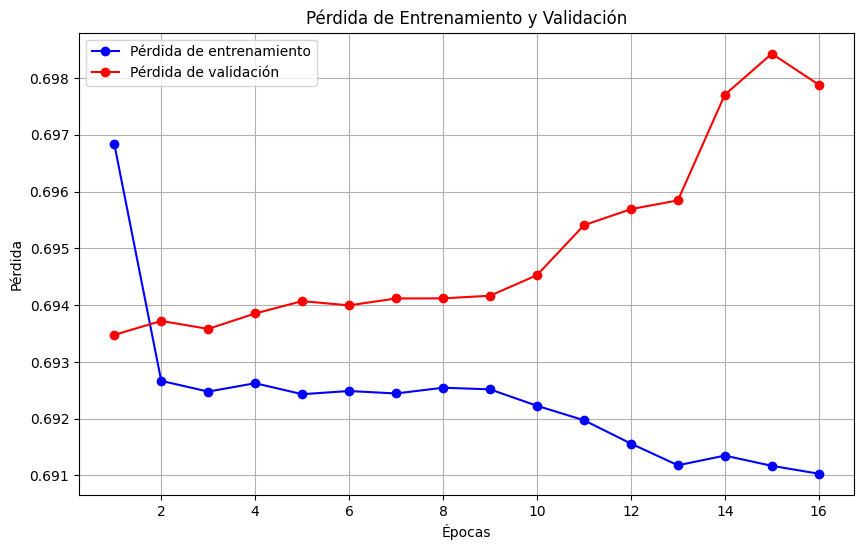

In [ ]:
import matplotlib.pyplot as plt

# Obtener los valores de pérdida del historial
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo-', label='Pérdida de entrenamiento')
plt.plot(epochs, val_loss, 'ro-', label='Pérdida de validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

## 5. Resumen Práctico del Modelizado
Al finalizar el cuaderno, podemos concluir que la efectividad del sistema reside en la armonía entre sus partes:

1. La Estructura: La jerarquía de capas (Input 7 -> Hidden 8/4 -> Output 1) permite que la información se destile desde datos crudos hasta una decisión probabilística.

2. La No Linealidad: Las funciones de activación ReLU en las capas ocultas rompen la rigidez matemática, mientras que la Sigmoide en la salida garantiza una interpretación coherente para el negocio bancario.

3. El Aprendizaje: El algoritmo de Backpropagation junto con el Descenso del Gradiente permite que cada peso sináptico asuma su responsabilidad sobre el error, ajustándose en cada época.

4. La Generalización: Mediante la normalización de datos y el uso de Early Stopping, nos aseguramos de que el modelo capture patrones generales del riesgo crediticio y no se limite a memorizar ruidos o casos específicos del pasado.

# Práctica: Clasificación de Dígitos con el Dataset MNIST
El objetivo es que la red reciba una imagen de 28x28 píxeles y determine qué número representa. Dado que tenemos 10 categorías posibles (los números del 0 al 9), este es un problema de Clasificación Multiclase

## 1. Carga y Preprocesamiento de Datos
Las imágenes son matrices de 28x28. Para un MLP básico, debemos "aplanarlas" en un vector y normalizar los valores de los píxeles (que van de 0 a 255) al rango 0 a 1 para facilitar la convergencia

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Cargamos el dataset directamente desde la librería de Keras
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalización: los píxeles pasan de [0, 255] a [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Visualización de la "Experiencia" de la Red
Antes de entrenar, es una buena práctica observar qué está viendo el modelo. Graficaremos una muestra de las imágenes del set de entrenamiento para confirmar que la normalización no alteró la legibilidad de los números.

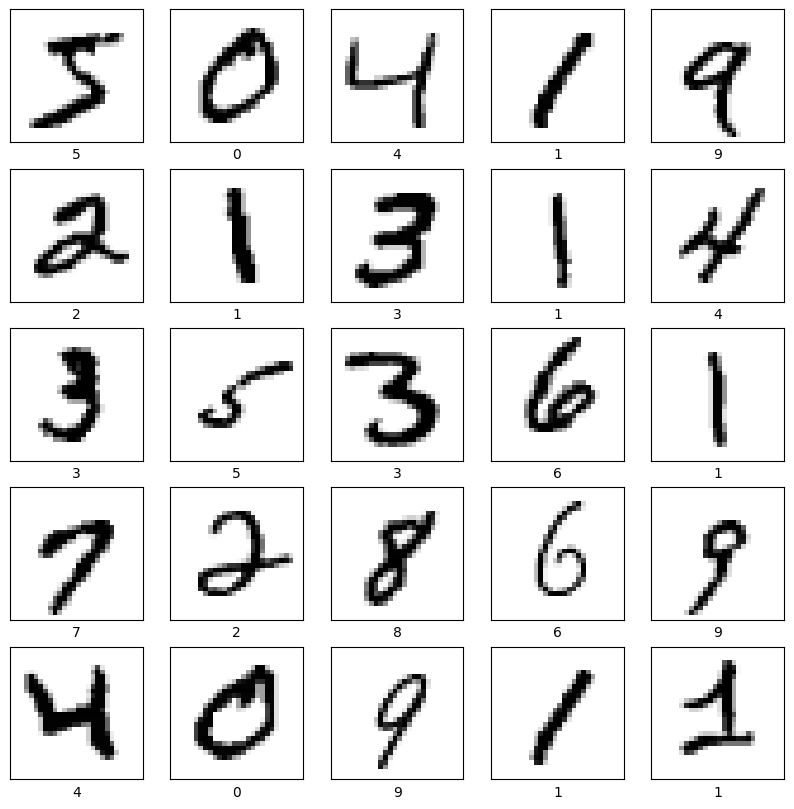

In [ ]:
import matplotlib.pyplot as plt

# Visualizamos las primeras 25 imágenes del dataset
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

## 2. Definición de la Arquitectura y Justificación
Aquí es donde aplicamos los criterios de diseño vistos en la teoría:

**Capa de Entrada (Flatten)**

Como las imágenes son de 28x28 píxeles, la capa de entrada debe tener exactamente 784 neuronas (28 * 28). Usamos Flatten para convertir la matriz en un vector unidireccional, cumpliendo con la regla de correspondencia exacta con las variables de entrada

**Capas Ocultas**

Añadiremos dos capas para permitir la abstracción de patrones.

* **Capa Oculta 1 (128 neuronas):** Un número mayor de neuronas al principio ayuda a capturar rasgos generales (curvas, bordes).

* **Capa Oculta 2 (64 neuronas):** Reducimos la cantidad para destilar la información en conceptos más específicos.


* **Activación ReLU:** Usamos ReLU en ambas para mantener la eficiencia y velocidad de entrenamiento.

**Capa de Salida**

Debe tener 10 neuronas, una por cada dígito posible (0 al 9). Usamos la función Softmax, que convierte las salidas en probabilidades que suman 1 (100%), permitiendo que el sistema elija el dígito con mayor probabilidad.

In [ ]:
model = models.Sequential([
    # Aplanamos la imagen de 28x28 a un vector de 784
    layers.Flatten(input_shape=(28, 28), name='Entrada_Aplanada'),

    # Capas ocultas con ReLU para capturar la no linealidad
    layers.Dense(128, activation='relu', name='Capa_Oculta_1'),
    layers.Dense(64, activation='relu', name='Capa_Oculta_2'),

    # Capa de salida: 10 neuronas con Softmax para clasificación multiclase
    layers.Dense(10, activation='softmax', name='Salida_Probabilistica')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada_Aplanada (Flatten)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_1 (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_Probabilistica (Dense)   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Compilación y Entrenamiento
Utilizaremos el optimizador **Adam** y la función de pérdida **sparse_categorical_crossentropy**, ideal cuando las etiquetas son números enteros.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Implementamos Early Stopping para evitar el sobreajuste
callback_parada = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Entrenamos el modelo
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[callback_parada]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9235 - loss: 0.2615 - val_accuracy: 0.9647 - val_loss: 0.1248
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9677 - loss: 0.1080 - val_accuracy: 0.9655 - val_loss: 0.1118
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9766 - loss: 0.0768 - val_accuracy: 0.9710 - val_loss: 0.0958
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9827 - loss: 0.0550 - val_accuracy: 0.9723 - val_loss: 0.0937
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9854 - loss: 0.0455 - val_accuracy: 0.9710 - val_loss: 0.1068
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9881 - loss: 0.0360 - val_accuracy: 0.9755 - val_loss: 0.1022
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9898 - loss: 0.0306 - val_accuracy: 0.9722 - val_loss: 0.1071


**¿Por qué esta configuración?**

La elección de 128 y 64 neuronas es un equilibrio: suficiente profundidad para que el MLP sea un aproximador universal de funciones capaz de entender los trazos de los números, pero no tan grande como para desperdiciar recursos o caer en el sobreajuste (memorización)

### Graficamos las curvas de aprendizaje
Como discutimos en la teoría, observar las curvas de pérdida (loss) y precisión (accuracy) es la mejor forma de detectar el sobreajuste . Si la curva de validación empieza a subir mientras la de entrenamiento baja, sabemos que es momento de aplicar la parada temprana .

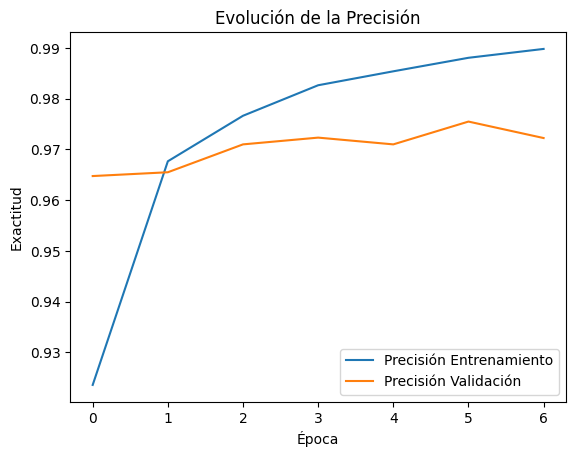

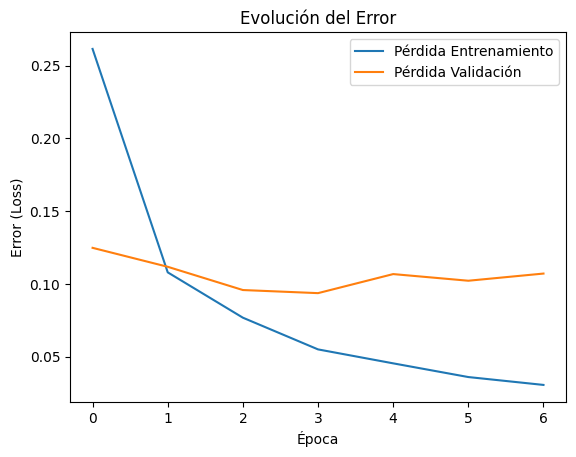

In [ ]:
# Graficamos la precisión
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label = 'Precisión Validación')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.title('Evolución de la Precisión')
plt.show()

# Graficamos la pérdida
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label = 'Pérdida Validación')
plt.xlabel('Época')
plt.ylabel('Error (Loss)')
plt.legend(loc='upper right')
plt.title('Evolución del Error')
plt.show()

## 4. Predicción e Interpretación (Función Softmax)
Ahora tomaremos una imagen del set de prueba que la red nunca ha visto. Al pasarla por el modelo, la capa de salida con función Softmax nos devolverá un vector de 10 probabilidades . La suma de estas probabilidades será igual a 1 (100%), y el sistema elegirá la categoría con el valor más alto como su "ganadora"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


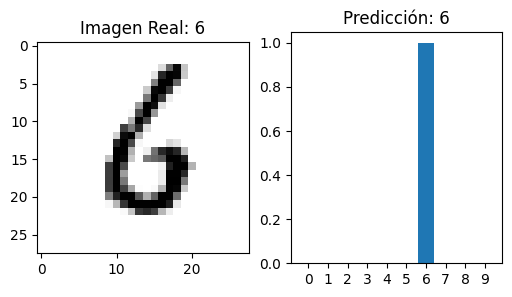

La red está un 99.80% segura de que es un 6


In [ ]:
# Seleccionamos una imagen al azar del set de test (ej. el índice 10)
img_index = 50
img = X_test[img_index]

# Preparamos la imagen para el modelo (añadimos la dimensión del batch)
img_batch = (np.expand_dims(img,0))

# Realizamos la predicción
predicciones = model.predict(img_batch)
clase_predicha = np.argmax(predicciones[0])

# Mostramos el resultado
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img, cmap=plt.cm.binary)
plt.title(f"Imagen Real: {y_test[img_index]}")

plt.subplot(1,2,2)
plt.bar(range(10), predicciones[0])
plt.xticks(range(10))
plt.title(f"Predicción: {clase_predicha}")
plt.show()

print(f"La red está un {predicciones[0][clase_predicha]*100:.2f}% segura de que es un {clase_predicha}")